In [1]:
import tensorly as tl
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from moabb.paradigms import P300,LeftRightImagery, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = LeftRightImagery(resample=250)
dataset = BNCI2014004()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[2],
     return_epochs=True
)
session = meta['session'].unique()[0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


BNCI2014004 has been renamed to BNCI2014_004. BNCI2014004 will be removed in version 1.1.
The dataset class name 'BNCI2014004' must be an abbreviation of its code 'BNCI2014-004'. See moabb.datasets.base.is_abbrev for more information.


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
680 matching events found
No baseline correction applied


/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr

In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor, hankel_tensor
import numpy as np
from mne.decoding import Scaler

X = epochs.get_data()
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X = stf_tensor(X, sfreq=epochs.info['sfreq'], normalize=True, log=True, n_freqs=4, bin_freq=4)
#X = hankel_tensor(X)
X = tl.tensor(X)
y = labels
X.shape

(120, 3, 4, 18)

In [5]:
import seaborn as sns
"""
x = X.flatten()
x = tl.to_numpy(x)
sns.distplot(x)
"""

'\nx = X.flatten()\nx = tl.to_numpy(x)\nsns.distplot(x)\n'

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/5, random_state=2, stratify=y)

In [7]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[1]*10,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
%time bttda.fit(X_train,y_train)

Fitting block 1/10...


Forward model :   9%|▉         | 12/128 [00:00<00:00, 201.40it/s]


Fitting block 2/10...


Forward model :  14%|█▍        | 18/128 [00:00<00:00, 300.12it/s]


Fitting block 3/10...


...

Forward model :  31%|███▏      | 40/128 [00:00<00:00, 324.92it/s]


Fitting block 10/10...


Forward model :  13%|█▎        | 17/128 [00:00<00:00, 208.11it/s]

CPU times: user 20.4 s, sys: 32.2 s, total: 52.6 s
Wall time: 4.87 s


BTTDA(extra_train_info=True,
      hoda_params={'delta': None, 'extra_train_info': False, 'init': 'random',
                   'max_iter': 128, 'obj': 'tr', 'random_state': 42, 'rank': 1,
                   'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                   'toeplitz': None, 'tol': 1e-08, 'verbose': True},
      ranks=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1], verbose=True)

In [8]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,log_loss,mse,nmse
0,1,"(1, 1, 1)",0.005310,0.010398,0.496938,0.983329,0.987708
1,2,"(1, 1, 1)",0.004387,0.016960,0.429121,0.972627,0.976957
2,3,"(1, 1, 1)",0.004228,0.019957,0.369989,0.968580,0.972893
3,4,"(1, 1, 1)",0.004190,0.026651,0.317482,0.962493,0.966778
4,5,"(1, 1, 1)",0.003935,0.030493,0.297708,0.957732,0.961997
5,6,"(1, 1, 1)",0.003824,0.034357,0.269521,0.948460,0.952683
6,7,"(1, 1, 1)",0.003548,0.035077,0.289591,0.942099,0.946294
7,8,"(1, 1, 1)",0.003363,0.036380,0.301626,0.937700,0.941876
8,9,"(1, 1, 1)",0.003301,0.039016,0.279395,0.933367,0.937523
9,10,"(1, 1, 1)",0.003223,0.043240,0.239698,0.923938,0.928052


<Axes: xlabel='block', ylabel='nmse'>

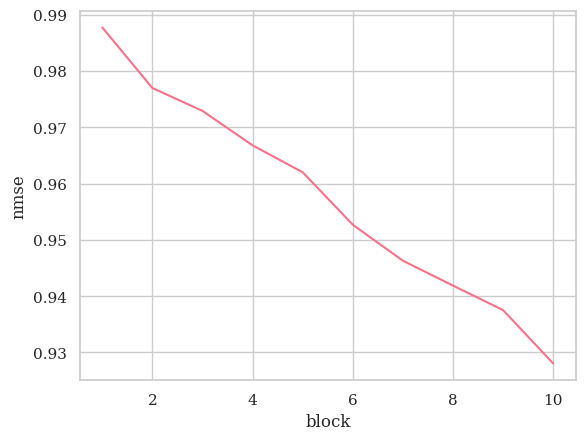

In [9]:
import seaborn as sns
sns.lineplot(data=df, x='block', y='nmse')

,mse,nmse,block
0,1.000764,0.983328,0
1,0.995377,0.978034,1
2,0.992294,0.975005,2
3,0.993687,0.976374,3
4,0.991547,0.974271,4
5,0.989289,0.972053,5
6,0.973262,0.956305,6
7,0.967222,0.950370,7
8,0.965044,0.948230,8
9,0.963876,0.947082,9


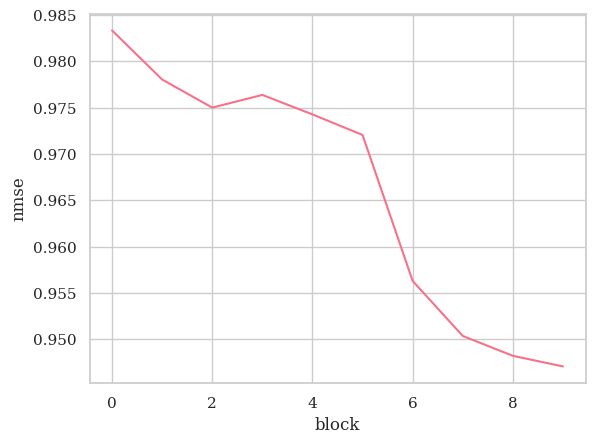

In [10]:
from hoda.hoda import forward_stats
info = []
for b in range(len(bttda.blocks_)):
    Xt_test = bttda.transform(X_test, blocks=bttda.blocks_[:b+1])
    X_rec_test = bttda.inv_transform(Xt_test, n_blocks=b+1)
    res = forward_stats(X_test, Xt_test, X_rec_test,y)
    res['block'] =b
    info.append(res)
info = pd.DataFrame(info)
sns.lineplot(data=info, x='block', y='nmse')
info

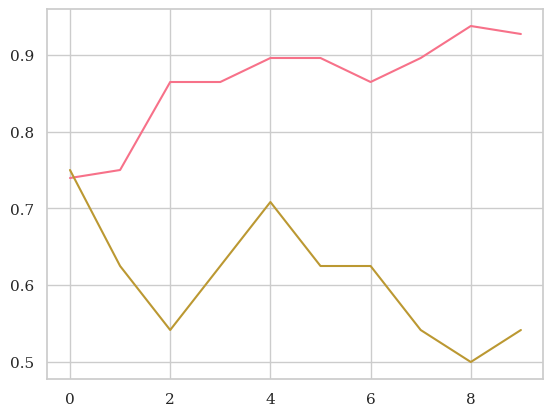

In [11]:
from hoda.hoda import forward_stats
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

score_train = []
score_test = []
for b in range(len(bttda.blocks_)):
    Xt_train = tl.to_numpy(bttda.transform(X_train, blocks=bttda.blocks_[:b+1]))
    Xt_test = tl.to_numpy(bttda.transform(X_test, blocks=bttda.blocks_[:b+1]))
    clf = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
    clf.fit(Xt_train,y_train)
    score_train.append(accuracy_score(y_train, clf.predict(Xt_train)))
    score_test.append(accuracy_score(y_test, clf.predict(Xt_test)))
plt.plot(score_train)
plt.plot(score_test)

<Axes: >

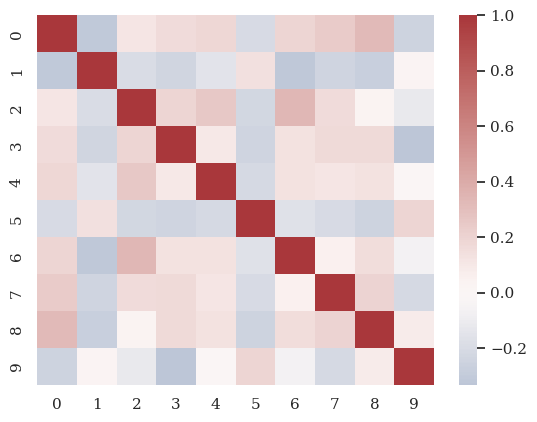

In [12]:
Xt = bttda.transform(X)
Xt = tl.to_numpy(Xt)
corr = np.corrcoef(Xt, rowvar=False)
sns.heatmap(corr, center=0, cmap='vlag')